In [1]:
print("Pairs trading project started")

Pairs trading project started


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


# Statistical Arbitrage Using Cointegrated Pairs

## Project idea

This project tests a simple pairs trading strategy using Coca-Cola (KO) and PepsiCo (PEP).

The idea is that if two related stocks move together historically, temporary divergence between them may create a trading opportunity.

## Steps

1. Download stock price data
2. Plot KO and PEP prices
3. Estimate the relationship between the two stocks
4. Build the spread
5. Convert spread into z-score
6. Generate trading signals
7. Backtest the strategy
8. Evaluate performance

In [3]:
#!pip install yfinance

In [4]:
import yfinance as yf

In [5]:
tickers = ["KO", "PEP"]

data = yf.download(tickers, start="2020-01-01", end="2025-12-31")

data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                   High                    Low  \
Ticker             KO         PEP         KO         PEP         KO   
Date                                                                  
2020-01-02  45.141273  110.945129  45.502468  112.096884  44.952464   
2020-01-03  44.894989  110.789932  45.141261  111.737474  44.402451   
2020-01-06  44.878574  111.214706  45.075592  111.353583  44.755441   
2020-01-07  44.533802  109.466614  44.821116  111.149344  44.451713   
2020-01-08  44.615898  110.030251  44.853960  110.569377  44.451721   

Price                        Open                Volume           
Ticker             PEP         KO         PEP        KO      PEP  
Date                                                              
2020-01-02  110.389662  45.412169  111.802816  11867700  3784100  
2020-01-03  110.381505  44.591257  110.651069  11354500  4000100  
2020-01-06  110.438697  44.862159  110.520388  14698300  4085100  
2020-01-07  109.417605  44.697983  111.092158   9973900  5718100  
2020-01-08  109.515641  44.550228  109.834214  10676000  3681400

In [6]:
prices = data["Close"]

prices.head()

Ticker,KO,PEP
Date,,
2020-01-02,45.141273,110.945129
2020-01-03,44.894989,110.789932
2020-01-06,44.878574,111.214706
2020-01-07,44.533802,109.466614
2020-01-08,44.615898,110.030251


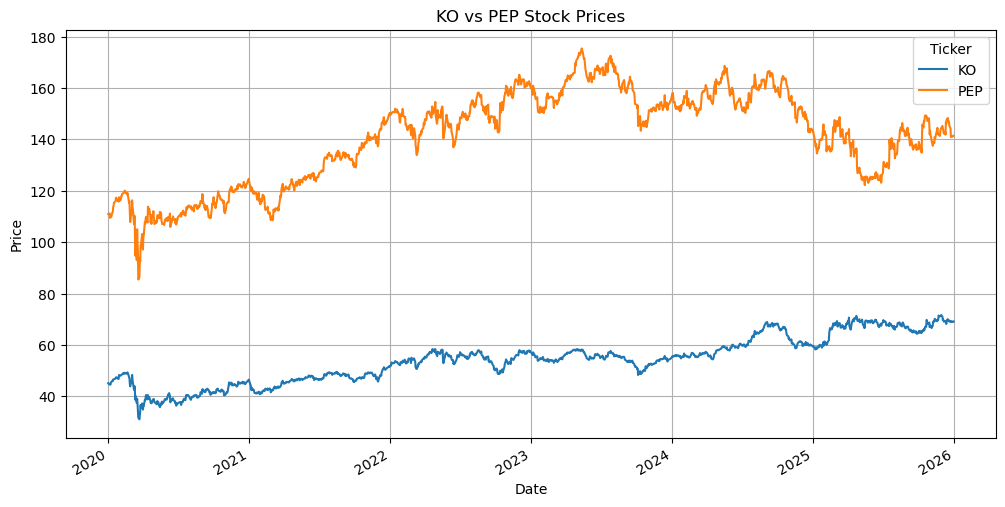

In [7]:
prices.plot(figsize=(12, 6))

plt.title("KO vs PEP Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

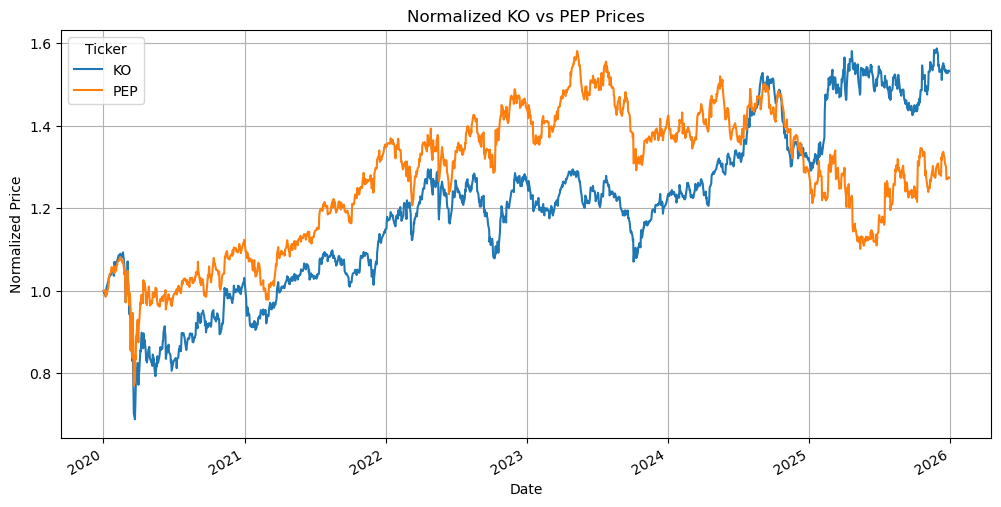

In [8]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))

plt.title("Normalized KO vs PEP Prices")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

In [9]:
import os
os.getcwd()

'/Users/didar'

Hedge Ratio (Beta): 0.2989


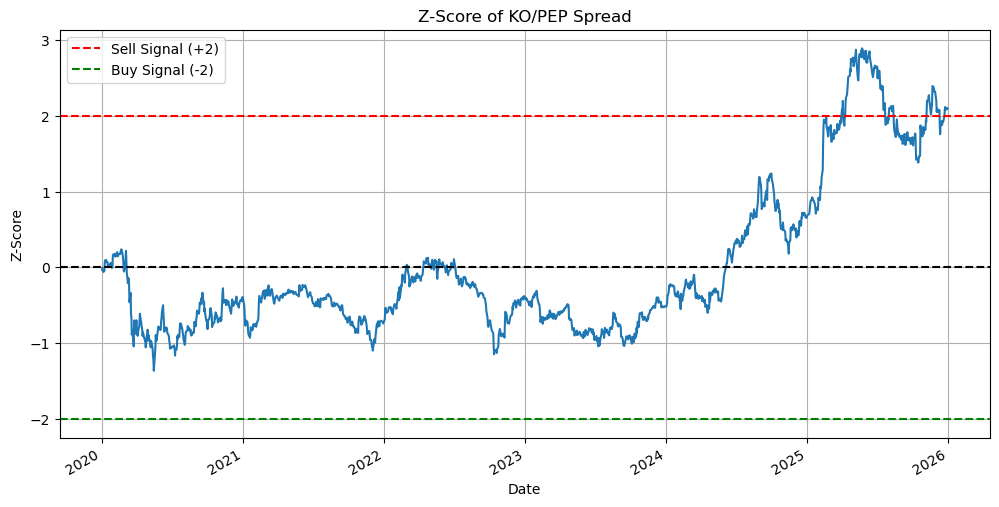

In [10]:
import statsmodels.api as sm

# 1. Считаем отношение цен (Hedge Ratio / Beta) через линейную регрессию OLS
X = sm.add_constant(prices['PEP']) 
model = sm.OLS(prices['KO'], X).fit()
beta = model.params['PEP']

print(f"Hedge Ratio (Beta): {beta:.4f}")

# 2. Строим Спред (Spread = KO - Beta * PEP)
spread = prices['KO'] - beta * prices['PEP']

# 3. Считаем Z-Score
mean = spread.mean()
std = spread.std()
z_score = (spread - mean) / std

# 4. Рисуем Z-score и торговые пороги (+2 и -2)
plt.figure(figsize=(12, 6))
z_score.plot()
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2.0, color='red', linestyle='--', label='Sell Signal (+2)')
plt.axhline(-2.0, color='green', linestyle='--', label='Buy Signal (-2)')
plt.title("Z-Score of KO/PEP Spread")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)
plt.show()

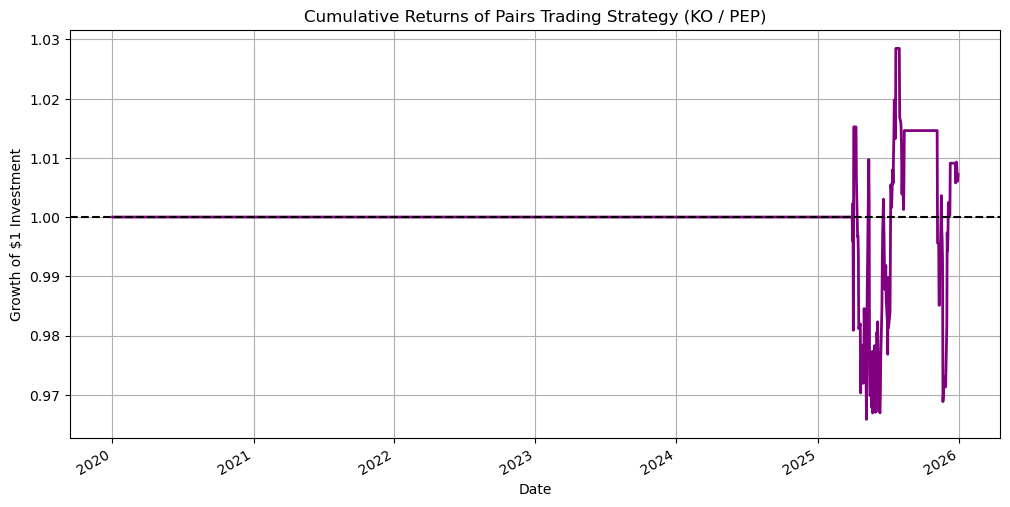

Total Cumulative Return: 0.72%


In [11]:
# 1. Создаем DataFrame для торговли
df = pd.DataFrame(index=prices.index)
df['KO'] = prices['KO']
df['PEP'] = prices['PEP']
df['Spread'] = spread
df['Z_Score'] = z_score

# 2. Генерируем торговые сигналы
# Long Spread (покупаем KO, продаем PEP): когда Z < -2
# Short Spread (продаем KO, покупаем PEP): когда Z > 2
df['Positions_KO'] = np.where(df['Z_Score'] < -2, 1, np.where(df['Z_Score'] > 2, -1, 0))
df['Positions_PEP'] = -beta * df['Positions_KO']

# Сдвигаем позиции на 1 день вперед (торгуем на следующий день после сигнала, без заглядывания в будущее)
df['Positions_KO'] = df['Positions_KO'].shift(1)
df['Positions_PEP'] = df['Positions_PEP'].shift(1)

# 3. Считаем ежедневную доходность акций
df['Returns_KO'] = df['KO'].pct_change()
df['Returns_PEP'] = df['PEP'].pct_change()

# 4. Считаем доходность портфеля и кумулятивный PnL
df['Strategy_Returns'] = (df['Positions_KO'] * df['Returns_KO']) + (df['Positions_PEP'] * df['Returns_PEP'])
df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

# 5. Строим график итоговой доходности
plt.figure(figsize=(12, 6))
df['Cumulative_Returns'].plot(color='purple', linewidth=2)
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Cumulative Returns of Pairs Trading Strategy (KO / PEP)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.grid(True)
plt.show()

# Выводим финальную доходность
total_return = (df['Cumulative_Returns'].iloc[-1] - 1) * 100
print(f"Total Cumulative Return: {total_return:.2f}%")

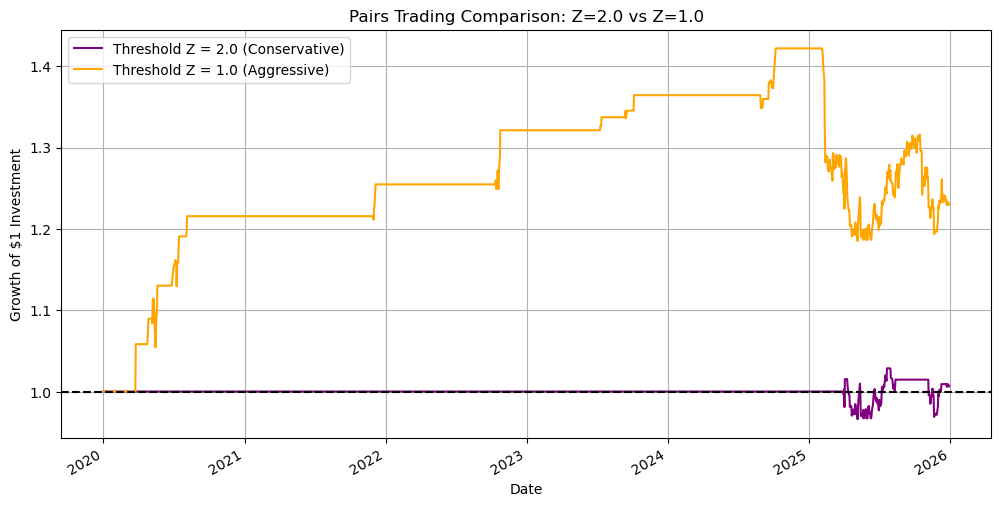

Optimized Cumulative Return (Z=1.0): 23.08%


In [12]:
# Попробуем более частый вход: Z_threshold = 1.0 вместо 2.0
z_thresh = 1.0

df['Positions_KO_opt'] = np.where(df['Z_Score'] < -z_thresh, 1, np.where(df['Z_Score'] > z_thresh, -1, 0))
df['Positions_PEP_opt'] = -beta * df['Positions_KO_opt']

df['Positions_KO_opt'] = df['Positions_KO_opt'].shift(1)
df['Positions_PEP_opt'] = df['Positions_PEP_opt'].shift(1)

df['Strategy_Returns_opt'] = (df['Positions_KO_opt'] * df['Returns_KO']) + (df['Positions_PEP_opt'] * df['Returns_PEP'])
df['Cumulative_Returns_opt'] = (1 + df['Strategy_Returns_opt'].fillna(0)).cumprod()

plt.figure(figsize=(12, 6))
df['Cumulative_Returns'].plot(label='Threshold Z = 2.0 (Conservative)', color='purple')
df['Cumulative_Returns_opt'].plot(label='Threshold Z = 1.0 (Aggressive)', color='orange')
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Pairs Trading Comparison: Z=2.0 vs Z=1.0")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.show()

total_return_opt = (df['Cumulative_Returns_opt'].iloc[-1] - 1) * 100
print(f"Optimized Cumulative Return (Z=1.0): {total_return_opt:.2f}%")

In [13]:
# Расчет Sharpe Ratio и Max Drawdown для Z=1.0
returns = df['Strategy_Returns_opt'].dropna()

# 1. Annualized Sharpe Ratio (предполагаем безрисковую ставку = 0)
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)

# 2. Maximum Drawdown
cum_rets = df['Cumulative_Returns_opt']
peak = cum_rets.cummax()
drawdown = (cum_rets - peak) / peak
max_drawdown = drawdown.min() * 100

print(f"--- Strategy Performance Metrics (Z=1.0) ---")
print(f"Total Return: {total_return_opt:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

--- Strategy Performance Metrics (Z=1.0) ---
Total Return: 23.08%
Sharpe Ratio: 0.50
Max Drawdown: -16.65%


In [14]:
# 1. Разделение на Train (60%) и Test (40%)
train_size = int(len(df) * 0.6)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

# 2. Обучение OLS ТОЛЬКО на Train data
X_train = sm.add_constant(train_df['PEP'])
model_train = sm.OLS(train_df['KO'], X_train).fit()
beta_train = model_train.params['PEP']

# 3. Применение Beta к Test data (Out-of-Sample)
test_df['Spread'] = test_df['KO'] - beta_train * test_df['PEP']
test_df['Mean'] = train_df['Spread'].mean()  # Среднее берем из TRAIN!
test_df['Std'] = train_df['Spread'].std()    # Std берем из TRAIN!
test_df['Z_Score'] = (test_df['Spread'] - test_df['Mean']) / test_df['Std']

# 4. Простой бэктест на Test data (Z = 1.0)
test_df['Position_KO'] = 0
test_df.loc[test_df['Z_Score'] > 1.0, 'Position_KO'] = -1
test_df.loc[test_df['Z_Score'] < -1.0, 'Position_KO'] = 1
test_df.loc[abs(test_df['Z_Score']) < 0.2, 'Position_KO'] = 0
test_df['Position_KO'] = test_df['Position_KO'].ffill().fillna(0)

test_df['KO_Returns'] = test_df['KO'].pct_change()
test_df['PEP_Returns'] = test_df['PEP'].pct_change()
test_df['Strategy_Returns'] = test_df['Position_KO'] * (test_df['KO_Returns'] - beta_train * test_df['PEP_Returns'])
test_df['OOS_Cumulative_Returns'] = (1 + test_df['Strategy_Returns']).cumprod()

print(f"Train Beta: {beta_train:.4f}")
print(f"Out-of-Sample Return: {(test_df['OOS_Cumulative_Returns'].iloc[-1] - 1) * 100:.2f}%")

Train Beta: 0.2990
Out-of-Sample Return: -27.82%


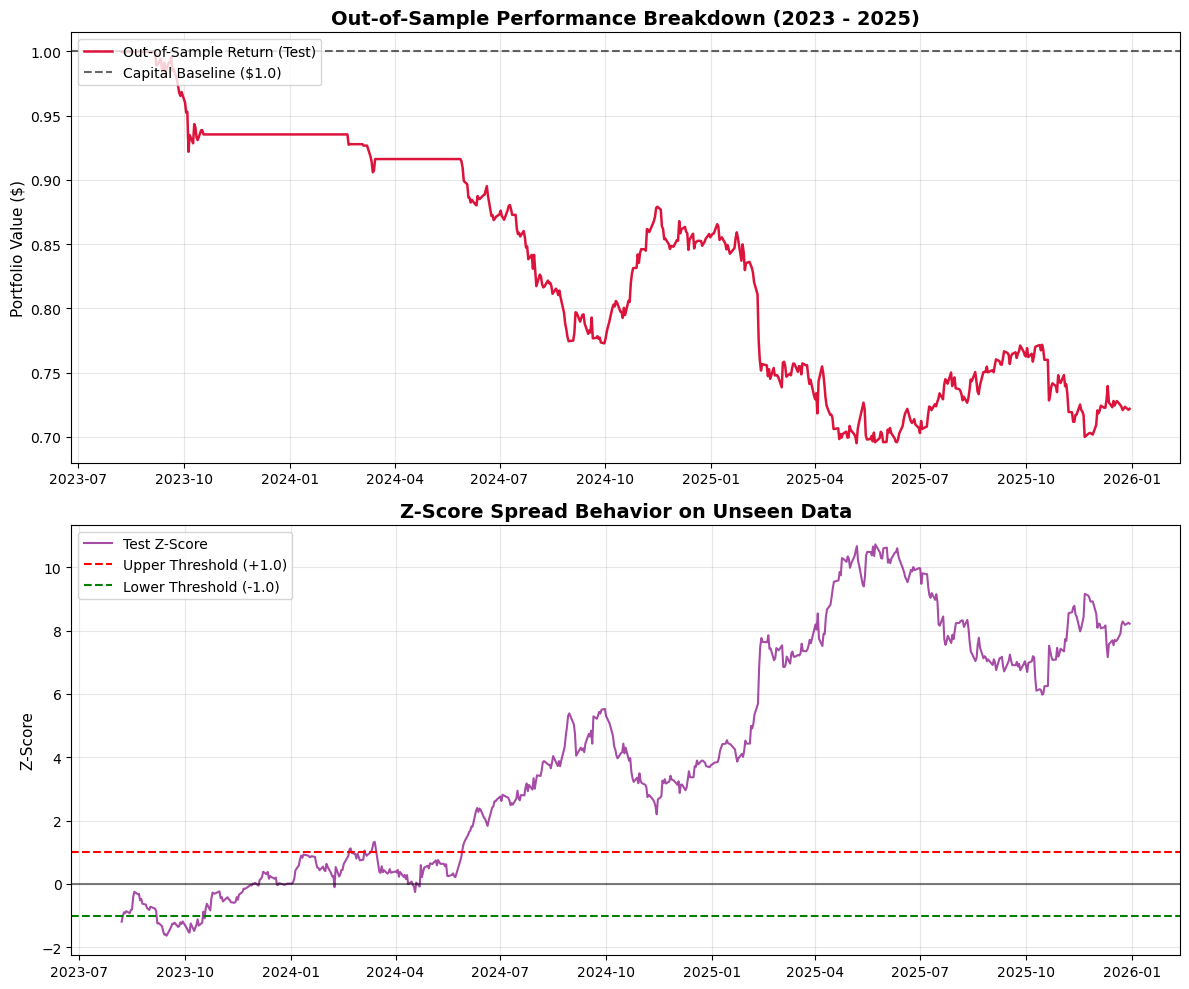

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# График 1: Out-of-Sample Накопленная Доходность (OOS Return)
axes[0].plot(test_df.index, test_df['OOS_Cumulative_Returns'], color='crimson', linewidth=1.8, label='Out-of-Sample Return (Test)')
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Capital Baseline ($1.0)')
axes[0].set_title('Out-of-Sample Performance Breakdown (2023 - 2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($)', fontsize=11)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# График 2: Z-Score спреда на Test периоде и линии входа
axes[1].plot(test_df.index, test_df['Z_Score'], color='purple', alpha=0.7, label='Test Z-Score')
axes[1].axhline(1.0, color='red', linestyle='--', label='Upper Threshold (+1.0)')
axes[1].axhline(-1.0, color='green', linestyle='--', label='Lower Threshold (-1.0)')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.5)
axes[1].set_title('Z-Score Spread Behavior on Unseen Data', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Z-Score', fontsize=11)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()